# Trabalho Final - Machine Learning

* Felipe
* Gabriel Otaviano - RA375245
* Eduardo Sá - RA

Neste trabalho, como parte do time de analistas da Quantum Finance, vocês deverão explorar uma base de dados originalmente utilizada para classificação de score de crédito, disponível no Kaggle (https://www.kaggle.com/datasets/parisrohan/credit-score-classification), utilizando técnicas de Análise Exploratória de Dados (EDA) e algoritmos de Machine Learning supervisionados. 


O objetivo é aplicar e interpretar os resultados obtidos, assim como criar um sistema que gere valor a partir da análise da base de dados.

**Modelo de Classificação Supervisionada**


Desenvolver um modelo de classificação supervisionada para prever a classificação de crédito dos indivíduos presentes na base.


Passos esperados:

1. Realizar uma análise exploratória dos dados (EDA) para entender as características principais da base e as relações entre variáveis; 2 pontos

2. Implementar um pipeline de modelo de classificação usando Random Forest, XGBoost e LightGBM. Use GridSearch para otimizar os parametros de cada modelo; 4 pontos

3. Avaliar os resultados utilizando a métrica mais adequada e **justifique** sua escolha; 2 pontos

4. Apresentar os resultados, indicando a métrica no conjunto de treino (train.csv) e explicar como o modelo pode ser utilizado para decisões financeiras. 2 pontos


Entregáveis:

1. Este jupyter compactado (.zip) notebook executado e com os resultados aparentes (não serão aceitos outros formatos)
2. Grupo com mínimo de 2 pessoas e, idealmente, 4. 

# Entregável:
## 1. Setup

In [1]:
# Carregamento de bibliotecas:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import LinearSVC
from sklearn.svm import SVC

In [2]:
# Carregando a base

In [3]:
df = pd.read_csv('train.csv')

C:\Users\gabri\AppData\Local\Temp\ipykernel_23400\2436019669.py:1: DtypeWarning: Columns (26: Monthly_Balance) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('train.csv')


In [4]:
# Cópia do DF bruto para segurança

df_raw = df.copy()

## 2. EDA

In [5]:
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [6]:
# Tipo dos dados e separação em categóricas e numéricas para uso posterior

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  str    
 1   Customer_ID               100000 non-null  str    
 2   Month                     100000 non-null  str    
 3   Name                      90015 non-null   str    
 4   Age                       100000 non-null  str    
 5   SSN                       100000 non-null  str    
 6   Occupation                100000 non-null  str    
 7   Annual_Income             100000 non-null  str    
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  str    
 13  Type_of_Loan              88592 non-null   str    
 14  

### Tratamento de colunas: Tipos
Vamos corrigir colunas numéricas que se encontram como strings antes de realizar tratamentos e análises:

"Annual_Income":

In [7]:
# Correção dos caractéres "_" presentes nos dados e conversão da coluna:

df['Annual_Income'] = df['Annual_Income'].str.replace('_', '')

df['Annual_Income'] = df['Annual_Income'].astype(np.float64)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  str    
 1   Customer_ID               100000 non-null  str    
 2   Month                     100000 non-null  str    
 3   Name                      90015 non-null   str    
 4   Age                       100000 non-null  str    
 5   SSN                       100000 non-null  str    
 6   Occupation                100000 non-null  str    
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  str    
 13  Type_of_Loan              88592 non-null   str    
 14  

"Age":

In [8]:
# Correção dos caractéres "_" e "-" presentes nos dados e conversão da coluna:

df['Age'] = df['Age'].str.replace('_', '')
df['Age'] = df['Age'].str.replace('-', '')

df['Age'] = df['Age'].astype(np.int64)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  str    
 1   Customer_ID               100000 non-null  str    
 2   Month                     100000 non-null  str    
 3   Name                      90015 non-null   str    
 4   Age                       100000 non-null  int64  
 5   SSN                       100000 non-null  str    
 6   Occupation                100000 non-null  str    
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  str    
 13  Type_of_Loan              88592 non-null   str    
 14  

"Num_of_Loan":

In [9]:
# Correção dos caractéres "_" e "-" presentes nos dados e conversão da coluna:

df['Num_of_Loan'] = df['Num_of_Loan'].str.replace('_', '')
df['Num_of_Loan'] = df['Num_of_Loan'].str.replace('-', '')

df['Num_of_Loan'] = df['Num_of_Loan'].astype(np.int64)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  str    
 1   Customer_ID               100000 non-null  str    
 2   Month                     100000 non-null  str    
 3   Name                      90015 non-null   str    
 4   Age                       100000 non-null  int64  
 5   SSN                       100000 non-null  str    
 6   Occupation                100000 non-null  str    
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  int64  
 13  Type_of_Loan              88592 non-null   str    
 14  

"Num_of_Delayed_Payment":

In [10]:
# Correção dos caractéres "_" e "-" presentes nos dados e conversão da coluna:

df['Num_of_Delayed_Payment'] = df['Num_of_Delayed_Payment'].str.replace('_', '')
df['Num_of_Delayed_Payment'] = df['Num_of_Delayed_Payment'].str.replace('-', '')

df['Num_of_Delayed_Payment'] = df['Num_of_Delayed_Payment'].astype(np.float64)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  str    
 1   Customer_ID               100000 non-null  str    
 2   Month                     100000 non-null  str    
 3   Name                      90015 non-null   str    
 4   Age                       100000 non-null  int64  
 5   SSN                       100000 non-null  str    
 6   Occupation                100000 non-null  str    
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  int64  
 13  Type_of_Loan              88592 non-null   str    
 14  

"Changed_Credit_Limit":

In [11]:
# Correção apenas do "_", já que é uma coluna percentual e deve manter valores negativos

df['Changed_Credit_Limit'] = df['Changed_Credit_Limit'].str.replace('_', '')

# Por possuir células apenas com o "_", convertemos elas para NaN antes de fazer a conversão do tipo de dado:

df['Changed_Credit_Limit'] = df['Changed_Credit_Limit'].replace('', np.nan)

df['Changed_Credit_Limit'] = df['Changed_Credit_Limit'].astype(np.float64)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  str    
 1   Customer_ID               100000 non-null  str    
 2   Month                     100000 non-null  str    
 3   Name                      90015 non-null   str    
 4   Age                       100000 non-null  int64  
 5   SSN                       100000 non-null  str    
 6   Occupation                100000 non-null  str    
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  int64  
 13  Type_of_Loan              88592 non-null   str    
 14  

"Outstanding_Debt":

In [12]:
# Correção apenas do "_", já que é uma coluna percentual e deve manter valores negativos

df['Outstanding_Debt'] = df['Outstanding_Debt'].str.replace('_', '')

df['Outstanding_Debt'] = df['Outstanding_Debt'].astype(np.float64)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  str    
 1   Customer_ID               100000 non-null  str    
 2   Month                     100000 non-null  str    
 3   Name                      90015 non-null   str    
 4   Age                       100000 non-null  int64  
 5   SSN                       100000 non-null  str    
 6   Occupation                100000 non-null  str    
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  int64  
 13  Type_of_Loan              88592 non-null   str    
 14  

"Amount_invested_monthly":

In [13]:
# Correção apenas do "_", já que é uma coluna percentual e deve manter valores negativos

df['Amount_invested_monthly'] = df['Amount_invested_monthly'].str.replace('_', '')

df['Amount_invested_monthly'] = df['Amount_invested_monthly'].astype(np.float64)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  str    
 1   Customer_ID               100000 non-null  str    
 2   Month                     100000 non-null  str    
 3   Name                      90015 non-null   str    
 4   Age                       100000 non-null  int64  
 5   SSN                       100000 non-null  str    
 6   Occupation                100000 non-null  str    
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  int64  
 13  Type_of_Loan              88592 non-null   str    
 14  

"Monthly_Balance":

In [14]:
# Correção apenas do "_", já que é uma coluna percentual e deve manter valores negativos

df['Monthly_Balance'] = df['Monthly_Balance'].str.replace('_', '')

df['Monthly_Balance'] = df['Monthly_Balance'].astype(np.float64)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  str    
 1   Customer_ID               100000 non-null  str    
 2   Month                     100000 non-null  str    
 3   Name                      90015 non-null   str    
 4   Age                       100000 non-null  int64  
 5   SSN                       100000 non-null  str    
 6   Occupation                100000 non-null  str    
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  int64  
 13  Type_of_Loan              88592 non-null   str    
 14  

Para a coluna "Credit_History_Age", faremos um outro processo, por estar formatada com texto e strings (exemplo: "22 Years and 1 Months"):

In [15]:
# Extrai anos e meses do texto e converte para uma única métrica (meses totais)

credit_age = df['Credit_History_Age'].str.extract(r'(\d+) Years? and (\d+) Months?')
credit_age = credit_age.astype(float)

df['Credit_History_Age_Months'] = credit_age[0] * 12 + credit_age[1]

df = df.drop(columns='Credit_History_Age')

In [16]:
df['Credit_History_Age_Months']

0        265.0
1          NaN
2        267.0
3        268.0
4        269.0
         ...  
99995    378.0
99996    379.0
99997    380.0
99998    381.0
99999    382.0
Name: Credit_History_Age_Months, Length: 100000, dtype: float64

## 3. Split Treino/Teste

Para a divisão da base entre Treino e Teste, foram dropadas as colunas de identificação dos clientes e seus IDs, pois são colunas sem poder preditivo para o modelo:

In [17]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Credit_Score', 'ID', 'Customer_ID', 'SSN', 'Name'])
y = df['Credit_Score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(80000, 23) (20000, 23)


In [18]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Credit_Score
Standard    0.531737
Poor        0.289988
Good        0.178275
Name: proportion, dtype: float64
Credit_Score
Standard    0.53175
Poor        0.28995
Good        0.17830
Name: proportion, dtype: float64


## 4. Tratamento pós-split (outliers e nulos, sem leakage)

Todo o tratamento de outliers e nulos foi movido para depois do split, garantindo que nenhuma estatística (percentil, mediana) seja calculada usando dados de teste. As transformações por cliente rodam separadamente em cada conjunto, e as regras de negócio (sem estatística) são aplicadas de forma idêntica nos dois.

### Outliers por percentil

`Annual_Income`, `Num_of_Delayed_Payment`, `Amount_invested_monthly` e `Total_EMI_per_month` não têm um teto óbvio de bom senso de domínio, então usamos percentil (99 para as três primeiras, 95 para `Total_EMI_per_month`, por ter uma cauda mais longa). O limite é calculado só com `X_train` e aplicado nos dois conjuntos, evitando que o teste influencie o corte.

In [19]:
limites_percentil = {
    'Annual_Income': 0.99,
    'Num_of_Delayed_Payment': 0.99,
    'Amount_invested_monthly': 0.99,
    'Total_EMI_per_month': 0.95,
}

for col, q in limites_percentil.items():
    limite = X_train[col].quantile(q)
    X_train[col] = X_train[col].clip(upper=limite)
    X_test[col] = X_test[col].clip(upper=limite)

X_train[list(limites_percentil.keys())].describe()

,Annual_Income,Num_of_Delayed_Payment,Amount_invested_monthly,Total_EMI_per_month
count,80000.000000,74405.000000,76395.000000,80000.000000
mean,51682.901613,13.448128,641.935071,112.820953
std,40158.079625,6.356691,2053.377785,117.361498
min,7005.930000,0.000000,0.000000,0.000000
25%,19419.650000,9.000000,74.627508,30.305498
50%,37482.370000,14.000000,135.939167,68.839655
75%,72678.605000,18.000000,265.526070,160.585877
max,179825.360000,27.000000,10000.000000,443.675781


### Outliers com teto fixo + correção de dado corrompido

`Age`, `Num_Bank_Accounts`, `Num_Credit_Card`, `Interest_Rate`, `Num_of_Loan` e `Num_Credit_Inquiries` usam tetos fixos de bom senso de domínio (ex.: idade acima de 100 anos é erro de imputação, não estatística calculada da base) — por isso não dependem do split, mas são aplicados aqui por padronização. `Monthly_Balance` recebe uma correção à parte: valores com ordem de grandeza impossível (ex.: -3,33e+26) são convertidos para nulo, por representarem corrupção de dado, não um outlier real.

In [20]:
tetos_fixos = {
    'Age': 100,
    'Num_Bank_Accounts': 15,
    'Num_Credit_Card': 15,
    'Interest_Rate': 40,
    'Num_of_Loan': 10,
    'Num_Credit_Inquiries': 20
}

for conjunto in [X_train, X_test]:
    for col, teto in tetos_fixos.items():
        conjunto[col] = conjunto[col].clip(upper=teto)
    conjunto['Num_Bank_Accounts'] = conjunto['Num_Bank_Accounts'].clip(lower=0)
    conjunto.loc[conjunto['Monthly_Balance'].abs() > 1e6, 'Monthly_Balance'] = np.nan

X_train[list(tetos_fixos.keys()) + ['Monthly_Balance']].describe()

,Age,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Num_Credit_Inquiries,Monthly_Balance
count,80000.000000,80000.000000,80000.00000,80000.000000,80000.000000,78451.000000,77705.000000
mean,35.150425,5.498125,5.74095,15.053313,3.815025,6.028362,401.935892
std,15.237840,2.800187,2.47614,9.359252,2.737449,4.255052,213.487542
min,14.000000,0.000000,0.00000,1.000000,0.000000,0.000000,0.088628
25%,25.000000,4.000000,4.00000,8.000000,2.000000,3.000000,269.986159
50%,33.000000,6.000000,5.00000,14.000000,3.000000,6.000000,336.208386
75%,42.000000,7.000000,7.00000,20.000000,6.000000,9.000000,469.315598
max,100.000000,15.000000,15.00000,40.000000,10.000000,20.000000,1602.040519


### Nulos por cliente

`Monthly_Inhand_Salary` e `Credit_History_Age_Months` usam informação do próprio cliente (`Customer_ID`) ao longo dos meses. Como `Customer_ID` foi removido de `X` antes do split, recuperamos o agrupamento a partir do `df` original, usando o índice preservado pelo `train_test_split`. A transformação roda separadamente em `X_train` e `X_test`, garantindo que nenhuma informação atravesse os dois conjuntos.

In [21]:
grupos_treino = df['Customer_ID'].loc[X_train.index]
grupos_teste = df['Customer_ID'].loc[X_test.index]

X_train['Monthly_Inhand_Salary'] = X_train.groupby(grupos_treino)['Monthly_Inhand_Salary'].transform(lambda x: x.ffill().bfill())
X_test['Monthly_Inhand_Salary'] = X_test.groupby(grupos_teste)['Monthly_Inhand_Salary'].transform(lambda x: x.ffill().bfill())

mediana_salario = X_train['Monthly_Inhand_Salary'].median()
X_train['Monthly_Inhand_Salary'] = X_train['Monthly_Inhand_Salary'].fillna(mediana_salario)
X_test['Monthly_Inhand_Salary'] = X_test['Monthly_Inhand_Salary'].fillna(mediana_salario)

X_train['Credit_History_Age_Months'] = X_train.groupby(grupos_treino)['Credit_History_Age_Months'].transform(lambda x: x.interpolate(method='linear', limit_direction='both'))
X_test['Credit_History_Age_Months'] = X_test.groupby(grupos_teste)['Credit_History_Age_Months'].transform(lambda x: x.interpolate(method='linear', limit_direction='both'))

mediana_historico = X_train['Credit_History_Age_Months'].median()
X_train['Credit_History_Age_Months'] = X_train['Credit_History_Age_Months'].fillna(mediana_historico)
X_test['Credit_History_Age_Months'] = X_test['Credit_History_Age_Months'].fillna(mediana_historico)

print(X_train[['Monthly_Inhand_Salary', 'Credit_History_Age_Months']].isnull().sum())
print(X_test[['Monthly_Inhand_Salary', 'Credit_History_Age_Months']].isnull().sum())

Monthly_Inhand_Salary        0
Credit_History_Age_Months    0
dtype: int64
Monthly_Inhand_Salary        0
Credit_History_Age_Months    0
dtype: int64


### Nulos por regra de negócio

`Occupation` (categoria `"_______"` → `"Not_Informed"`) e `Type_of_Loan` (`"No_Loan"` para quem não tem empréstimo, `"Not_Specified"` para os casos de corrupção de dado já identificados) usam regras fixas, sem estatística agregada — por isso são seguras de aplicar em qualquer ordem, mas mantidas aqui por consistência com o restante do tratamento.

In [22]:
for conjunto in [X_train, X_test]:
    conjunto['Occupation'] = conjunto['Occupation'].replace('_______', 'Not_Informed')

    sem_emprestimo = conjunto['Type_of_Loan'].isnull() & (conjunto['Num_of_Loan'] == 0)
    conjunto.loc[sem_emprestimo, 'Type_of_Loan'] = 'No_Loan'

    nao_especificado = conjunto['Type_of_Loan'].isnull() & (conjunto['Num_of_Loan'] == 10)
    conjunto.loc[nao_especificado, 'Type_of_Loan'] = 'Not_Specified'

print(X_train[['Occupation', 'Type_of_Loan']].isnull().sum())
print(X_test[['Occupation', 'Type_of_Loan']].isnull().sum())

Occupation      0
Type_of_Loan    0
dtype: int64
Occupation      0
Type_of_Loan    0
dtype: int64


### Nulos por mediana simples

`Num_of_Delayed_Payment`, `Changed_Credit_Limit`, `Num_Credit_Inquiries`, `Amount_invested_monthly` e `Monthly_Balance` não têm relação clara com outra coluna nem com o comportamento do cliente, então usamos mediana — calculada apenas com `X_train` e aplicada nos dois conjuntos, para não vazar estatística do teste.

In [23]:
colunas_mediana = ['Num_of_Delayed_Payment', 'Changed_Credit_Limit',
                    'Num_Credit_Inquiries', 'Amount_invested_monthly', 'Monthly_Balance']

for col in colunas_mediana:
    mediana_treino = X_train[col].median()
    X_train[col] = X_train[col].fillna(mediana_treino)
    X_test[col] = X_test[col].fillna(mediana_treino)

print(X_train[colunas_mediana].isnull().sum())
print(X_test[colunas_mediana].isnull().sum())

Num_of_Delayed_Payment     0
Changed_Credit_Limit       0
Num_Credit_Inquiries       0
Amount_invested_monthly    0
Monthly_Balance            0
dtype: int64
Num_of_Delayed_Payment     0
Changed_Credit_Limit       0
Num_Credit_Inquiries       0
Amount_invested_monthly    0
Monthly_Balance            0
dtype: int64


### Conferência final

Verificação de que nenhum nulo restou em nenhuma coluna, em nenhum dos dois conjuntos, antes de seguir para a modelagem.

In [24]:
print(X_train.isnull().sum())
print(X_test.isnull().sum())

Month                        0
Age                          0
Occupation                   0
Annual_Income                0
Monthly_Inhand_Salary        0
Num_Bank_Accounts            0
Num_Credit_Card              0
Interest_Rate                0
Num_of_Loan                  0
Type_of_Loan                 0
Delay_from_due_date          0
Num_of_Delayed_Payment       0
Changed_Credit_Limit         0
Num_Credit_Inquiries         0
Credit_Mix                   0
Outstanding_Debt             0
Credit_Utilization_Ratio     0
Payment_of_Min_Amount        0
Total_EMI_per_month          0
Amount_invested_monthly      0
Payment_Behaviour            0
Monthly_Balance              0
Credit_History_Age_Months    0
dtype: int64
Month                        0
Age                          0
Occupation                   0
Annual_Income                0
Monthly_Inhand_Salary        0
Num_Bank_Accounts            0
Num_Credit_Card              0
Interest_Rate                0
Num_of_Loan               

### Relação de variáveis numéricas com o target

Selecionamos 5 variáveis com relevância conceitual para o domínio de crédito (renda, dívida em aberto, atraso de pagamento, número de contas bancárias e taxa de juros) e comparamos sua distribuição entre as três classes de `Credit_Score`, usando apenas o conjunto de treino.

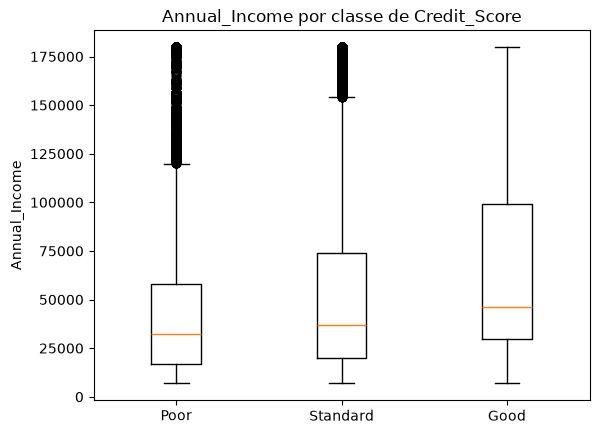

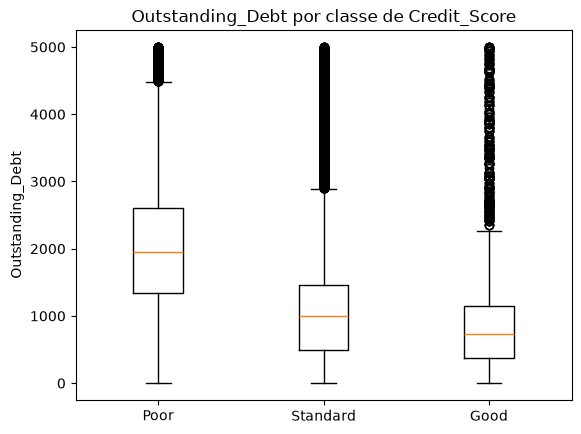

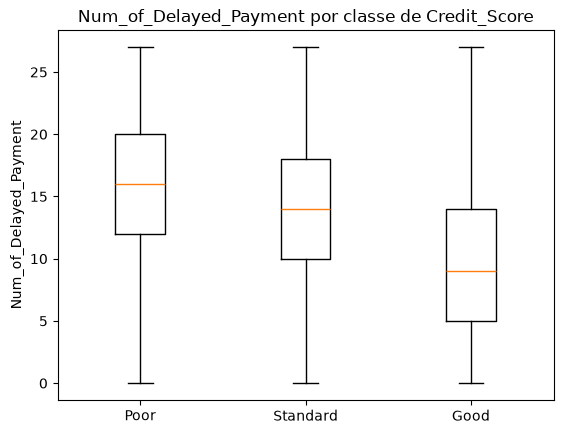

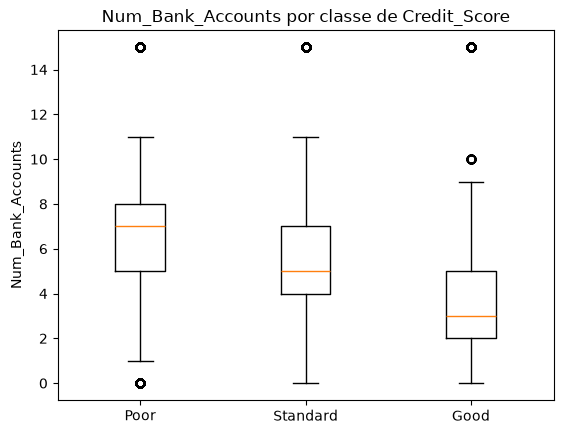

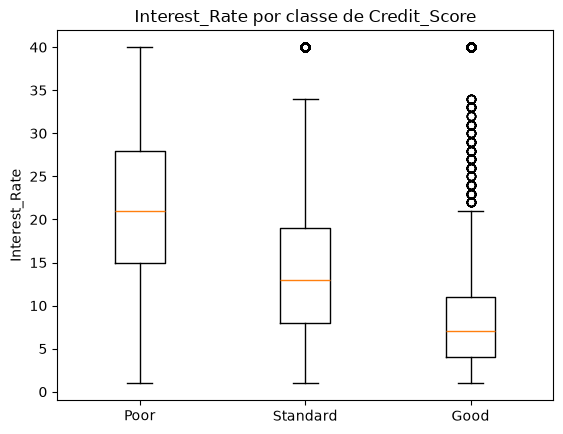

In [31]:
colunas_target = ['Annual_Income', 'Outstanding_Debt', 'Num_of_Delayed_Payment', 
                   'Num_Bank_Accounts', 'Interest_Rate']

for col in colunas_target:
    ordem_classes = ['Poor', 'Standard', 'Good']
    dados_por_classe = [X_train.loc[y_train == classe, col] for classe in ordem_classes]
    plt.figure()
    plt.boxplot(dados_por_classe, tick_labels=ordem_classes)
    plt.title(f'{col} por classe de Credit_Score')
    plt.ylabel(col)
    plt.show()

### Correlação entre variáveis numéricas

Analisamos a correlação entre as variáveis numéricas do conjunto de treino para identificar possível multicolinearidade, relevante para a etapa de modelagem.

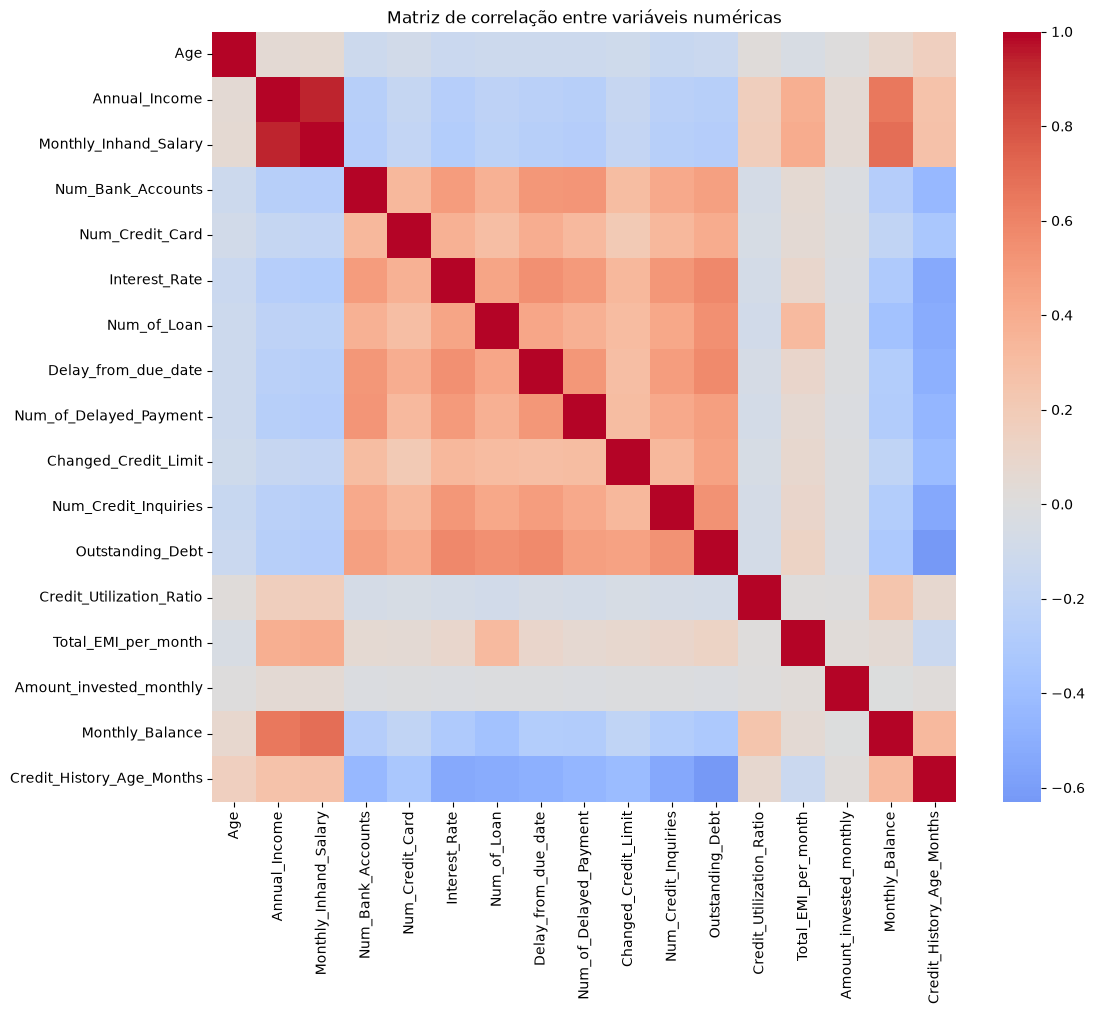

In [30]:
import seaborn as sns

colunas_numericas = X_train.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(12, 10))
sns.heatmap(X_train[colunas_numericas].corr(), annot=False, cmap='coolwarm', center=0)
plt.title('Matriz de correlação entre variáveis numéricas')
plt.show()

### Conclusão da EDA

A análise confirmou desbalanceamento relevante no target (Standard ~53%, Poor ~29%, Good ~18%), o que orientará a escolha da métrica de avaliação na etapa de modelagem. As cinco variáveis analisadas (`Annual_Income`, `Outstanding_Debt`, `Num_of_Delayed_Payment`, `Num_Bank_Accounts`, `Interest_Rate`) mostraram separação clara entre as classes, no sentido esperado pelo domínio de crédito: clientes com melhor score têm maior renda, menor dívida, menos atrasos, menos contas bancárias e juros mais baixos.

A matriz de correlação não indicou multicolinearidade severa entre a maioria das variáveis, com exceção de `Annual_Income` e `Monthly_Inhand_Salary` (correlação forte, ~0,7-0,8), que carregam informação redundante — um ponto a considerar na etapa de modelagem (ex.: manter apenas uma das duas). Um bloco de variáveis ligadas a risco de crédito (`Num_Bank_Accounts`, `Interest_Rate`, `Num_of_Loan`, `Num_of_Delayed_Payment`, `Outstanding_Debt`, `Num_Credit_Inquiries`) mostrou correlação moderada positiva entre si e negativa com `Credit_History_Age_Months`, sugerindo que clientes com histórico de crédito mais longo tendem a apresentar menos sinais de risco.

Com o tratamento de tipos, outliers e nulos concluído sem vazamento de dados entre treino e teste, e a relação das variáveis com o target validada, a base está pronta para a etapa de modelagem (Random Forest, XGBoost e LightGBM com GridSearch).